### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [4]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")
llm.invoke("Hello")

c:\D_Drive\RAGUdemy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hello". We need to respond appropriately. It\'s a normal greeting. No policy issues. Just respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 72, 'total_tokens': 116, 'completion_time': 0.093338858, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.003334234, 'prompt_tokens_details': None, 'queue_time': 0.050670055, 'total_time': 0.096673092}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db41f-94b3-76b3-ac13-171f2a5048da-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 44, 'total_tokens': 116, 'output_token_details': {'reasoning': 26}})

### We Will start With Creating Nodes

In [8]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

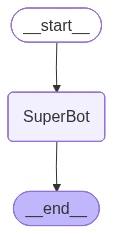

In [9]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [10]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Bharathy And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Bharathy And I like cricket', additional_kwargs={}, response_metadata={}, id='b59f4392-94ac-472d-9758-406df59545fd'),
  AIMessage(content="Hello Bharathy! 👋 Nice to meet you.  \n\nCricket is such an exciting sport—there’s always something happening, whether it’s a thrilling chase, a spectacular spin spell, or a massive six. Do you have a favorite team or player you follow? And are you more into Test matches, ODIs, T20s, or maybe the IPL? I'd love to hear more about what you enjoy most about cricket!", additional_kwargs={'reasoning_content': 'We need to respond. The user introduced themselves, says they like cricket. We should respond in a friendly manner, perhaps ask about cricket preferences, ask about favorite team, etc. Follow policies: no disallowed content. Just normal conversation.'}, response_metadata={'token_usage': {'completion_tokens': 145, 'prompt_tokens': 82, 'total_tokens': 227, 'completion_time': 0.308349716, 'completion_t

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

![image.png](attachment:image.png)

#### Streaming The Responses With Stream Method

In [11]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Krish! 👋 Great to meet you.  \n\nCricket’s such a fun sport—do you have a favorite team or player you follow? And are you more into the Test format, ODIs, T20s, or maybe a bit of everything? Let’s chat!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Krish And I like cricket". Likely they want a response, perhaps a greeting, ask about cricket, maybe ask for favorite team. The guidelines: respond friendly, ask follow-up. No disallowed content. So respond with greeting, ask about cricket preferences.'}, response_metadata={'token_usage': {'completion_tokens': 130, 'prompt_tokens': 82, 'total_tokens': 212, 'completion_time': 0.272124332, 'completion_tokens_details': {'reasoning_tokens': 63}, 'prompt_time': 0.003358234, 'prompt_tokens_details': None, 'queue_time': 0.051615166, 'total_time': 0.275482566}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d81b3304b3', 'service_tier': 'on_demand', 'finish_r

In [12]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='a95aa445-be25-4d50-ba8c-7cf48c9e8731'), AIMessage(content='Hey Krish! 👋 Great to meet you.  \n\nCricket’s such a fun sport—do you have a favorite team or player you follow? And are you more into the Test format, ODIs, T20s, or maybe a bit of everything? Let’s chat!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Krish And I like cricket". Likely they want a response, perhaps a greeting, ask about cricket, maybe ask for favorite team. The guidelines: respond friendly, ask follow-up. No disallowed content. So respond with greeting, ask about cricket preferences.'}, response_metadata={'token_usage': {'completion_tokens': 130, 'prompt_tokens': 82, 'total_tokens': 212, 'completion_time': 0.272124332, 'completion_tokens_details': {'reasoning_tokens': 63}, 'prompt_time': 0.003358234, 'prompt_tokens_details': None, 'queue_time': 0.051615166, 'tot

In [13]:
for chunk in graph_builder.stream({'messages':"I also like football "},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Got it—football’s right up there with cricket on your watchlist! ⚽️🏏\n\n### Quick “What’s Your Style?” poll\n| Sport | Your Preference |\n|-------|-----------------|\n| **Cricket** | Test | ODI | T20 |\n| **Football** | Club football (Premier League, La\u202fLiga, etc.) | International (World Cup, Euros) | Both |\n\n### A few fun crossover facts\n1. **Cricketers who love football** – Former England captain **Alastair Cook** is a lifelong Arsenal fan, while Indian star **Virat Kohli** follows Manchester City closely.\n2. **Footballers who try cricket** – England’s former striker **Wayne Rooney** once bowled a few overs in a charity cricket match, and Australian footballer **Harry Kewell** has been spotted playing backyard cricket during off‑season trips.\n3. **Stadium vibes** – Many cricket grounds (e.g., Melbourne Cricket Ground) have hosted big football matches, giving fans a chance to soak up both atmospheres in one venue.\n\n### How abou

In [14]:
for chunk in graph_builder.stream({'messages':"I Love sports "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='a95aa445-be25-4d50-ba8c-7cf48c9e8731'), AIMessage(content='Hey Krish! 👋 Great to meet you.  \n\nCricket’s such a fun sport—do you have a favorite team or player you follow? And are you more into the Test format, ODIs, T20s, or maybe a bit of everything? Let’s chat!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Krish And I like cricket". Likely they want a response, perhaps a greeting, ask about cricket, maybe ask for favorite team. The guidelines: respond friendly, ask follow-up. No disallowed content. So respond with greeting, ask about cricket preferences.'}, response_metadata={'token_usage': {'completion_tokens': 130, 'prompt_tokens': 82, 'total_tokens': 212, 'completion_time': 0.272124332, 'completion_tokens_details': {'reasoning_tokens': 63}, 'prompt_time': 0.003358234, 'prompt_tokens_details': None, 'queue_time': 0.051615166, 'tot

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [16]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019db424-38d6-7781-a0ed-c9c2b1a3655b', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='a95aa445-be25-4d50-ba8c-7cf48c9e8731'), AIMessage(content='Hey Krish! 👋 Great to meet you.  \n\nCricket’s such a fun sport—do you have a favorite team or player you follow? And are you more into the Test format, ODIs, T20s, or maybe a bit of everything? Let’s chat!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Krish And I like cricket". Likely they want a response, perhaps a greeting, ask about cricket, maybe ask for favorite team. The guidelines: respond friendly, ask follow-up. No disallowed content. So respond with g